<a href="https://colab.research.google.com/github/MalakMaher780/Traffic-Flow-Graph-Modeling-GNN-Visualization/blob/main/GNN_for_Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip traffic.csv.zip

Archive:  traffic.csv.zip
  inflating: traffic.csv             


In [ ]:
import pandas as pd
df = pd.read_csv('traffic.csv')

In [ ]:
import numpy as np

# A '1' means a connection exists; the diagonal is all '1' for self-loops.
# Rows/Cols 0, 1, 2, 3 correspond to Junctions 1, 2, 3, 4.
tilde_A = np.array([
    [1, 1, 0, 0], # Junction 1: Connected to self and Junction 2
    [1, 1, 1, 1], # Junction 2: Connected to self, J1, J3, and J4 (The Hub) [cite: 49]
    [0, 1, 1, 1], # Junction 3: Connected to self, J2, and J4
    [0, 1, 1, 1]  # Junction 4: Connected to self, J2, and J3
])
print("--- Graph Structure (Adjacency Matrix with Self-Loops) ---")
print(tilde_A)
print("\n")

--- Graph Structure (Adjacency Matrix with Self-Loops) ---
[[1 1 0 0]
 [1 1 1 1]
 [0 1 1 1]
 [0 1 1 1]]




In [ ]:
# Values taken from your traffic.csv for the 2017-01-01 timestamp
X_features = np.array([
    [27], # Vehicles at Junction 1
    [7],  # Vehicles at Junction 2
    [10], # Vehicles at Junction 3
    [3]   # Vehicles at Junction 4
])

In [ ]:
# --- PART 4: THE GNN OPERATION ---
learned_weight = 0.2

print("--- Step 1: Matrix Multiplication (tilde_A * X_features) ---")
print("(This naturally aggregates knowledge from neighbors!)")
# This is the 'Aggregation' step from the PDF
aggregated_values = np.matmul(tilde_A, X_features)
print(aggregated_values)
print("\n")

print("--- Step 2: Linear Transformation (Aggregation * Weight) ---")
print(f"(Applying the learned weight W = {learned_weight})")
# This is the 'Transformation' step from the PDF
final_output = aggregated_values * learned_weight
print(final_output)
print("\n")

--- Step 1: Matrix Multiplication (tilde_A * X_features) ---
(This naturally aggregates knowledge from neighbors!)
[[34]
 [47]
 [20]
 [20]]


--- Step 2: Linear Transformation (Aggregation * Weight) ---
(Applying the learned weight W = 0.2)
[[6.8]
 [9.4]
 [4. ]
 [4. ]]




In [ ]:
# --- PART 5: FINAL COMPARISON ---
print("--- Final Comparison (Latent State vs. Original Knowledge) ---")
junctions = ["Junction 1", "Junction 2", "Junction 3", "Junction 4"]

for i, junction in enumerate(junctions):
    orig = X_features[i][0]
    latent = final_output[i][0]
    # format output with 1 decimal place as shown in the doctor's results
    print(f"{junction}: Original Vehicles = {orig:.1f} | GNN Latent State = {latent:.1f}")

--- Final Comparison (Latent State vs. Original Knowledge) ---
Junction 1: Original Vehicles = 27.0 | GNN Latent State = 6.8
Junction 2: Original Vehicles = 7.0 | GNN Latent State = 9.4
Junction 3: Original Vehicles = 10.0 | GNN Latent State = 4.0
Junction 4: Original Vehicles = 3.0 | GNN Latent State = 4.0


/tmp/ipykernel_15814/2445330665.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G.add_node(name, orig=float(X_features[i]), latent=float(final_output[i]))


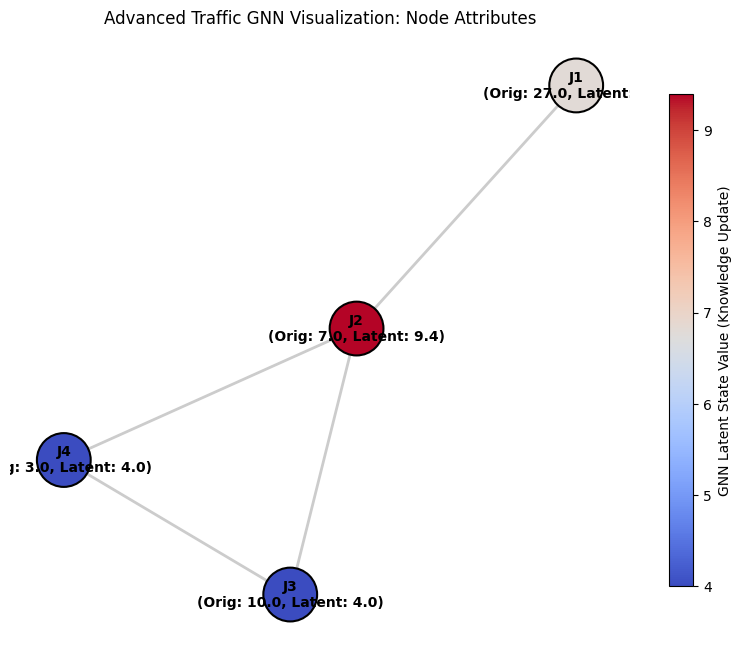

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Initialize the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 8))
plt.title("Advanced Traffic GNN Visualization: Node Attributes")

# 2. Create the Graph Object
G = nx.Graph()

# 3. Define Nodes with Attributes (Original X and Latent H)
# Values based on our previous GNN calculation results
junctions = ["J1", "J2", "J3", "J4"]
for i, name in enumerate(junctions):
    G.add_node(name, orig=float(X_features[i]), latent=float(final_output[i]))

# 4. Define Edges (Physical Connections between Junctions)
G.add_edges_from([("J1", "J2"), ("J2", "J3"), ("J3", "J4"), ("J4", "J2")])

# 5. Extract Attributes for Color Mapping
latent_features = [G.nodes[node]['latent'] for node in G.nodes]
cmap = plt.cm.coolwarm  # Red for High Latent, Blue for Low Latent
pos = nx.spring_layout(G, seed=42) # Consistent layout

# 6. Draw the Graph Components
# Draw Nodes with color intensity based on Latent State
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=latent_features,
                       cmap=cmap, edgecolors='black', linewidths=1.5, ax=ax)

# Draw Edges with specific width
nx.draw_networkx_edges(G, pos, width=2, edge_color='#cccccc', ax=ax)

# 7. Add Detailed Data Labels (Orig: X, Latent: H)
# This mirrors the label logic on Page 8 of the PDF
labels = {node: f"{node}\n(Orig: {data['orig']:.1f}, Latent: {data['latent']:.1f})"
          for node, data in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold', ax=ax)

# 8. Add Colorbar with Explicit Axes Linking
# This connects the node colors to the latent values visually
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(vmin=min(latent_features), vmax=max(latent_features)))
sm.set_array([]) # Required for ScalarMappable to initialize

fig.colorbar(sm, ax=ax, label='GNN Latent State Value (Knowledge Update)',
             orientation='vertical', shrink=0.8)

# 9. Final Display Settings
plt.axis('off') # Hide standard x/y axes for a clean graph look
plt.show()